# Mixed layer salinity budget analysis of ACCESS-OM2 runs

This notebook contains code to analyse the mixed layer salinity budget in ACCESS-OM2 for a given time period or event of interest.

This notebook relies on pre-computed grouped budget quantities as computed by the budget processing scripts in this repository (e.g. `Process_Online_Budget.ipynb` or `spawn_process_online_budget.py` with `process_online_budget_year_salinity.sub`).

The theory behind this budget and the diagnostics used to analyse it are summarized in `Theory_and_Diagnostics.ipynb`, and in a paper in preparation.

This notebook has been minimally modified from `Mixed_Layer_Temperature_Budget.ipynb`. It has not been carefully checked - please use at your own risk.

In [1]:
#Load required packages
%matplotlib inline
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import cftime
from tqdm import tqdm

import cmocean as cm
import sys, os
import datetime

from dask.distributed import Client

In [2]:
# Load workers:
client = Client(n_workers=7)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44167 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/44167/status,
Dashboard: /proxy/44167/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40423,Workers: 0
Dashboard: /proxy/44167/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41527,Total threads: 1
Dashboard: /proxy/39329/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:42407,


In [3]:
# change directory to Figures/ subfolder for saving images
os.chdir('access-om2-analysis/access-om2-sst-budget/Figures')

# Load data

### Define paths, region and time period to load data for

In [75]:
base = '/scratch/e14/rmh561/access-om2/archive/025deg_jra55_iaf_cycle6_online_mlt/'          # Location of simulation output
pp_diags_folder = base + 'post_processed_diags/'                                                  # Temp folder where post-processed diagnostics (pre-processed budgets) are contained

# Choose year to consider:
output = 364 # 364 = 2017
#output = 365 # 365 = 2018
#output = 366 # 366 = 2019 - contains 3D daily budget diagnostics for quantifying correlation errors
base2 = base + 'output%03d/ocean/' % output

# Climatology:
clim_str = 'output336-365' # 336-365 = 1989-2018
clim_label = '1989-2018'

# Region to load:
reg = [-90, -10, -30, 30] # Atlantic

# Time period to load:
times = slice('2017-05-01',None)
times_snap = slice('2017-05-01',None) # Note; this must be 1 more than times.

# Chunks to use:
chunks2D = {'time':1,'yt_ocean':216,'xt_ocean':240}
chunks3D = {'time':1,'st_ocean':25,'yt_ocean':324,'xt_ocean':360}

# Set constants:
rho0 = 1035.
Cp = 3992.10322329649

### Load standard daily and grid data

In [76]:
# Grid file:
ds_grid = xr.open_dataset(base2 + 'ocean_grid.nc',chunks=chunks2D).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))#.isel(time=times)

# Standard daily variables:
ds_day = xr.open_dataset(base2 + 'ocean_daily.nc',decode_times=False,chunks=chunks2D).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_day = ds_day.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_day.time.values]})
ds_day.average_DT.data = ds_day.average_DT*np.timedelta64(1,'D')
ds_day = ds_day.sel(time=times)

/jobfs/158605673.gadi-pbs/ipykernel_3965740/3959564957.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds_day = xr.open_dataset(base2 + 'ocean_daily.nc',decode_times=False,chunks=chunks2D).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))


### Load pre-computed MLS budget terms
These files contain pre-computed grouped MLS budget terms. Computed using `process_online_budget_year_salinity.sub` and `spawn_process_online_budget.py`.

The resulting dataset `mls_budget_stavg_daily` will contain x*y*t arrays with the above budget groups (e.g. advection, surface forcing etc.) as well as:
- fixedh\_tendency: The tendency term of mixed layer salinity with a fixed ML depth (i.e. the sum of all the RHS terms listed above, including the correction terms).
- residual: The residual, fixedh\_tendency minus all the RHS terms. This should be exactly zero. If it isn't, you're missing terms in the source MOM5 budget or something has gone wrong.
- mls\_tendency: The tendency of the mixed layer salinity computed (in this case) from snapshots of the mixed layer salinity (the diagnostic salt\_in\_mld, divided by $\rho_0$) at the start and end of the day.
- entrainment: The entrainment term, computed by residual mls\_tendency - fixedh\_tendency (with the later here equal to the sum of the RHS terms, so the mls budget closes)

All terms have units of psu/second.

We also optionally load a climatology of the same budget files. Note: to compute these, just use `ncea *.nc output.nc` from the command line, including all the years desired.

In [77]:
# Pre-computed standard average online daily
mls_budget_stavg_daily = xr.open_dataset(pp_diags_folder + 'mls_budget/mls_budget_stavg_daily_online_output%03d.nc' % output).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3])).sel(time=times)

In [78]:
# Pre-computed standard average online climatology (1989-2018, outputs 336-365):
mls_budget_stavg_clim = xr.open_dataset(pp_diags_folder + 'mls_budget/mls_budget_stavg_daily_online_' + clim_str + '_monthly_mean.ncea.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))

### Load climatologies of selected standard variables

In [79]:
# Standard average daily budget diagnostics:
ds_clim = xr.open_dataset(pp_diags_folder + 'ocean_month_' + clim_str + '.clim.nc',decode_times=False).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_clim_snapshot = xr.open_dataset(pp_diags_folder + 'ocean_snapshot_month_' + clim_str + '.clim.nc',decode_times=False).sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3])).load()

# Fix time variable by decoding time by hand (see https://forum.access-hive.org.au/t/cftime-vs-datetime64-time-encoding-issues-with-access-om2-025-omip-2-run/4085);
ds_clim = ds_clim.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_clim.time.values]})
ds_clim_snapshot = ds_clim_snapshot.assign_coords({'time':[np.datetime64('0001-01-01') + np.timedelta64(int(x*86400),'s') for x in ds_clim_snapshot.time.values]})

# Add wrap-around for clim_snapshot:
tminus1 = str(ds_clim_snapshot.time.isel(time=-1).values)
tminus1 = np.datetime64(str(int(tminus1[:4])-1) + tminus1[4:])
ds_clim_snapshot = xr.concat([ds_clim_snapshot.isel(time=-1).assign_coords({'time':tminus1}),ds_clim_snapshot],dim='time')

# Analyse a specific event/region

This section contains various plotting features to analyse an event of interest.

First, define the region of interest (for spatial averaging) and its name:

In [80]:
sreg = [-75, -60, 12, 16] # western Atlantic
region_name = 'Western Tropical Atlantic'

## Plot time series of mixed layer salinity, mixed layer depth and budget terms averaged over the event region

Then, compute a daily-resolution climatology covering the period of interest

In [81]:
add_extra = True # Whether to add a second year in the climatologies in order to cover the second half of December

year = int(str(ds_day.time[0].astype('datetime64[Y]').values)[:4])
year_clim = int(str(ds_clim.time[0].astype('datetime64[Y]').values)[:4])

# climatology, standard variables:
ds_climA = ds_clim.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean']).assign_coords({'time':[np.datetime64(str(x.values).replace(str(year_clim),str(year))) for x in ds_clim.time]})
if add_extra:
    ds_clim2 = ds_clim.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean']).assign_coords({'time':[np.datetime64(str(x.values).replace(str(year_clim),str(year+1))) for x in ds_clim.time]})
    ds_climA = xr.concat([ds_climA,ds_clim2],dim='time')
ds_climA = ds_climA.resample(time='1D').interpolate("linear").sel(time=times)

# Climatology, budget variables:
mls_budget_stavg_climA = mls_budget_stavg_clim.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean']).assign_coords({'time':[np.datetime64(str(x.values).replace(str(year_clim),str(year))) for x in mls_budget_stavg_clim.time]})
if add_extra:
    mls_budget_stavg_clim2 = mls_budget_stavg_clim.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean']).assign_coords({'time':[np.datetime64(str(x.values).replace(str(year_clim),str(year+1))) for x in mls_budget_stavg_clim.time]})
    mls_budget_stavg_climA = xr.concat([mls_budget_stavg_climA,mls_budget_stavg_clim2],dim='time')
mls_budget_stavg_climA = mls_budget_stavg_climA#.resample(time='1D').interpolate("linear").sel(time=times)

Finally, plot the time series

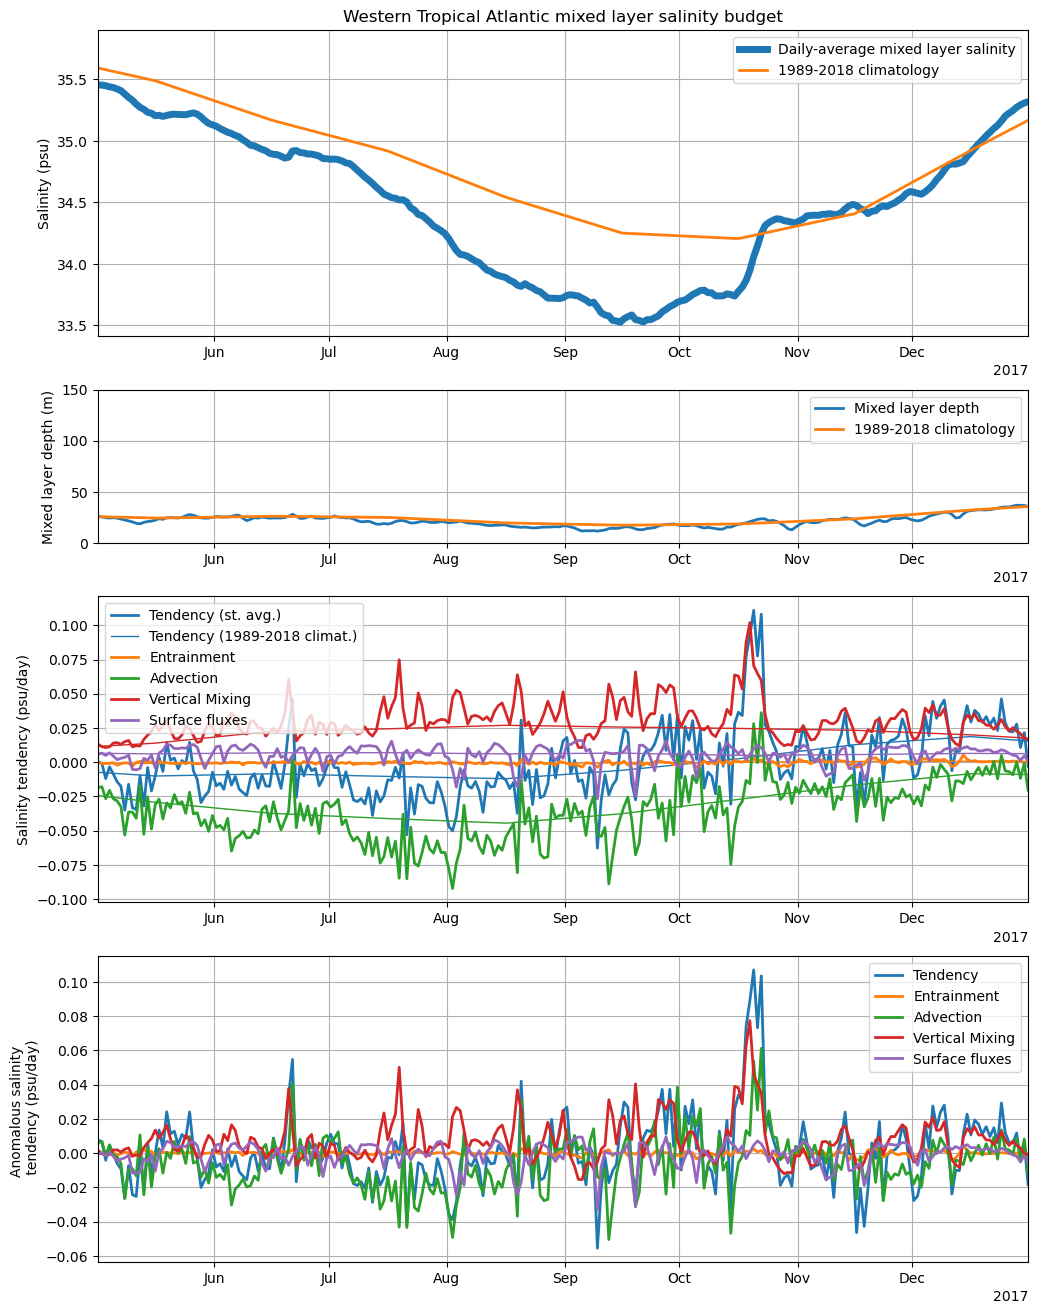

In [82]:
fig, axes = plt.subplots(nrows=4,ncols=1,figsize=(12,16),height_ratios=[1.,0.5,1.,1.])

# Panel 1: Mixed layer salinity, including climatology and snapshots:
mls = (ds_day.salt_in_mld/rho0).sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean'])
mls.plot(ax=axes[0],label='Daily-average mixed layer salinity',linewidth=5.)
(ds_climA.salt_in_mld/rho0).plot(ax=axes[0],label=clim_label + ' climatology',linewidth=2.)

axes[0].legend()
axes[0].set_title(region_name + ' mixed layer salinity budget')
axes[0].set_ylabel('Salinity (psu)')
axes[0].grid()

# Panel 2: Mixed layer depth and climatology:
ds_day.mld.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean']).plot(ax=axes[1],linewidth=2.,label='Mixed layer depth')
(ds_climA.mld).plot(ax=axes[1],label=clim_label + ' climatology',linewidth=2.)
axes[1].set_ylabel('Mixed layer depth (m)')
axes[1].grid()
axes[1].legend()
axes[1].set_ylim([0.,150.])

# Panel 3: Budget terms (raw)
vars = ['mls_tendency','entrainment','advection','vert_mixing','surface_flux']
labels = ['Tendency','Entrainment','Advection','Vertical Mixing','Surface fluxes']

budget_stavg = mls_budget_stavg_daily.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean'])
budget_stavg_clim = mls_budget_stavg_climA
unit_conv = 86400

for j, var in enumerate(vars):
    if j == 0:
        (budget_stavg[var]*unit_conv).plot(ax=axes[2],color='C' + str(j),linewidth=2.,label=labels[j] + ' (st. avg.)')
        (budget_stavg_clim[var]*unit_conv).plot(ax=axes[2],color='C' + str(j),linewidth=1.,label=labels[j] + ' (' + clim_label + ' climat.)')
    else:
        (budget_stavg[var]*unit_conv).plot(ax=axes[2],color='C' + str(j),linewidth=2.,label=labels[j])
        (budget_stavg_clim[var]*unit_conv).plot(ax=axes[2],color='C' + str(j),linewidth=1)
axes[2].legend()
axes[2].set_ylabel('Salinity tendency (psu/day)')
axes[2].grid()

# Panel 4: Budget terms (anomalies):

budget_stavg_clim_daily = mls_budget_stavg_climA.interp(time=budget_stavg.time.astype('datetime64[s]'))
for j, var in enumerate(vars):
    ((budget_stavg[var]-budget_stavg_clim_daily[var])*unit_conv).plot(ax=axes[3],color='C' + str(j),linewidth=2,label=labels[j])
axes[3].legend()
axes[3].set_ylabel('Anomalous salinity \n tendency (psu/day)')
axes[3].grid()

for ax in axes:
    ax.set_xlabel('')
    ax.set_xlim([mls.time[0],mls.time[-1]])
    
plt.savefig('mls_budget_' + region_name.replace(' ','') + '_time_series_with_anomalies.png',dpi=250,bbox_inches='tight')

## Plot spatial plot of mixed layer salinity anomalies during event

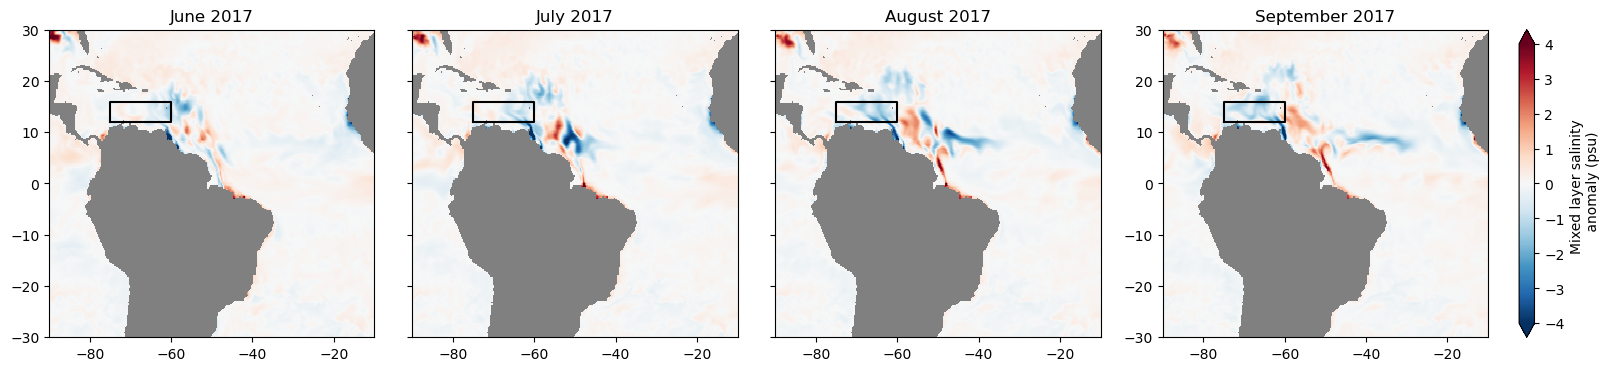

In [83]:
fig, axes = plt.subplots(nrows=1,ncols=4,figsize=(16,3.6),layout='constrained')

mls = (ds_day.salt_in_mld.resample(time='1ME').mean()/rho0)
mls_clim = (ds_clim.salt_in_mld/rho0)
clim = 4
(mls.sel(time='2017-06').drop_vars(['time'])-mls_clim.sel(time='1989-06').drop_vars(['time'])).plot(ax=axes[0],vmin=-clim,vmax=clim,cmap='RdBu_r',add_colorbar=False)
(mls.sel(time='2017-07').drop_vars(['time'])-mls_clim.sel(time='1989-07').drop_vars(['time'])).plot(ax=axes[1],vmin=-clim,vmax=clim,cmap='RdBu_r',add_colorbar=False)
(mls.sel(time='2017-08').drop_vars(['time'])-mls_clim.sel(time='1989-08').drop_vars(['time'])).plot(ax=axes[2],vmin=-clim,vmax=clim,cmap='RdBu_r',add_colorbar=False)
(mls.sel(time='2017-09').drop_vars(['time'])-mls_clim.sel(time='1989-09').drop_vars(['time'])).plot(ax=axes[3],vmin=-clim,vmax=clim,cmap='RdBu_r',cbar_kwargs={'label': 'Mixed layer salinity \n anomaly (psu)'})

axes[0].set_title('June 2017')
axes[1].set_title('July 2017')
axes[2].set_title('August 2017')
axes[3].set_title('September 2017')
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor([0.5,0.5,0.5])
    ax.plot([sreg[0],sreg[1],sreg[1],sreg[0],sreg[0]],[sreg[2],sreg[2],sreg[3],sreg[3],sreg[2]],'-k')
axes[1].set_yticklabels([])
axes[2].set_yticklabels([])

plt.savefig('mls_' + region_name.replace(' ','') + '_2017.png',dpi=300,bbox_inches='tight')

## Spatial plots of monthly time-averaged budget anomalies

In [84]:
# Time integrate daily budget to get monthly budget (units are degrees celsius change over that month, so degC/month accounting for the different lengths of months):
mls_budget_stavg_monthly = (mls_budget_stavg_daily*(ds_day.average_DT/np.timedelta64(1,'s'))).resample(time='1ME').sum()
mls_budget_stavg_monthly = mls_budget_stavg_monthly.assign_coords({'time':mls_budget_stavg_monthly.time.astype('datetime64[M]')}) # Replace time stamp with year-month only (to match climatology)

# Compute budget anomalies by subtracting climatology:
year = int(str(ds_day.time[0].astype('datetime64[Y]').values)[:4])                # Year of interest
mon_len = (ds_day.average_DT/np.timedelta64(1,'s')).resample(time='1ME').sum()    # Length of month in seconds   
mon_len = mon_len.assign_coords({'time':mon_len.time.astype('datetime64[M]')})    
anomaly_budget = mls_budget_stavg_monthly - mls_budget_stavg_clim.assign_coords({'time':[np.datetime64(str(year) + '-01')+np.timedelta64(x,'M') for x in range(12)]})*mon_len # Subtract climatology (times length of month in seconds to get same units)

# Compute spatial averages for each month over focus region (for bar plots further down):
anomaly_budget_av = (anomaly_budget*ds_grid.area_t).sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean'])/ds_grid.area_t.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(['xt_ocean','yt_ocean'])

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 155.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 77.93 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/cl

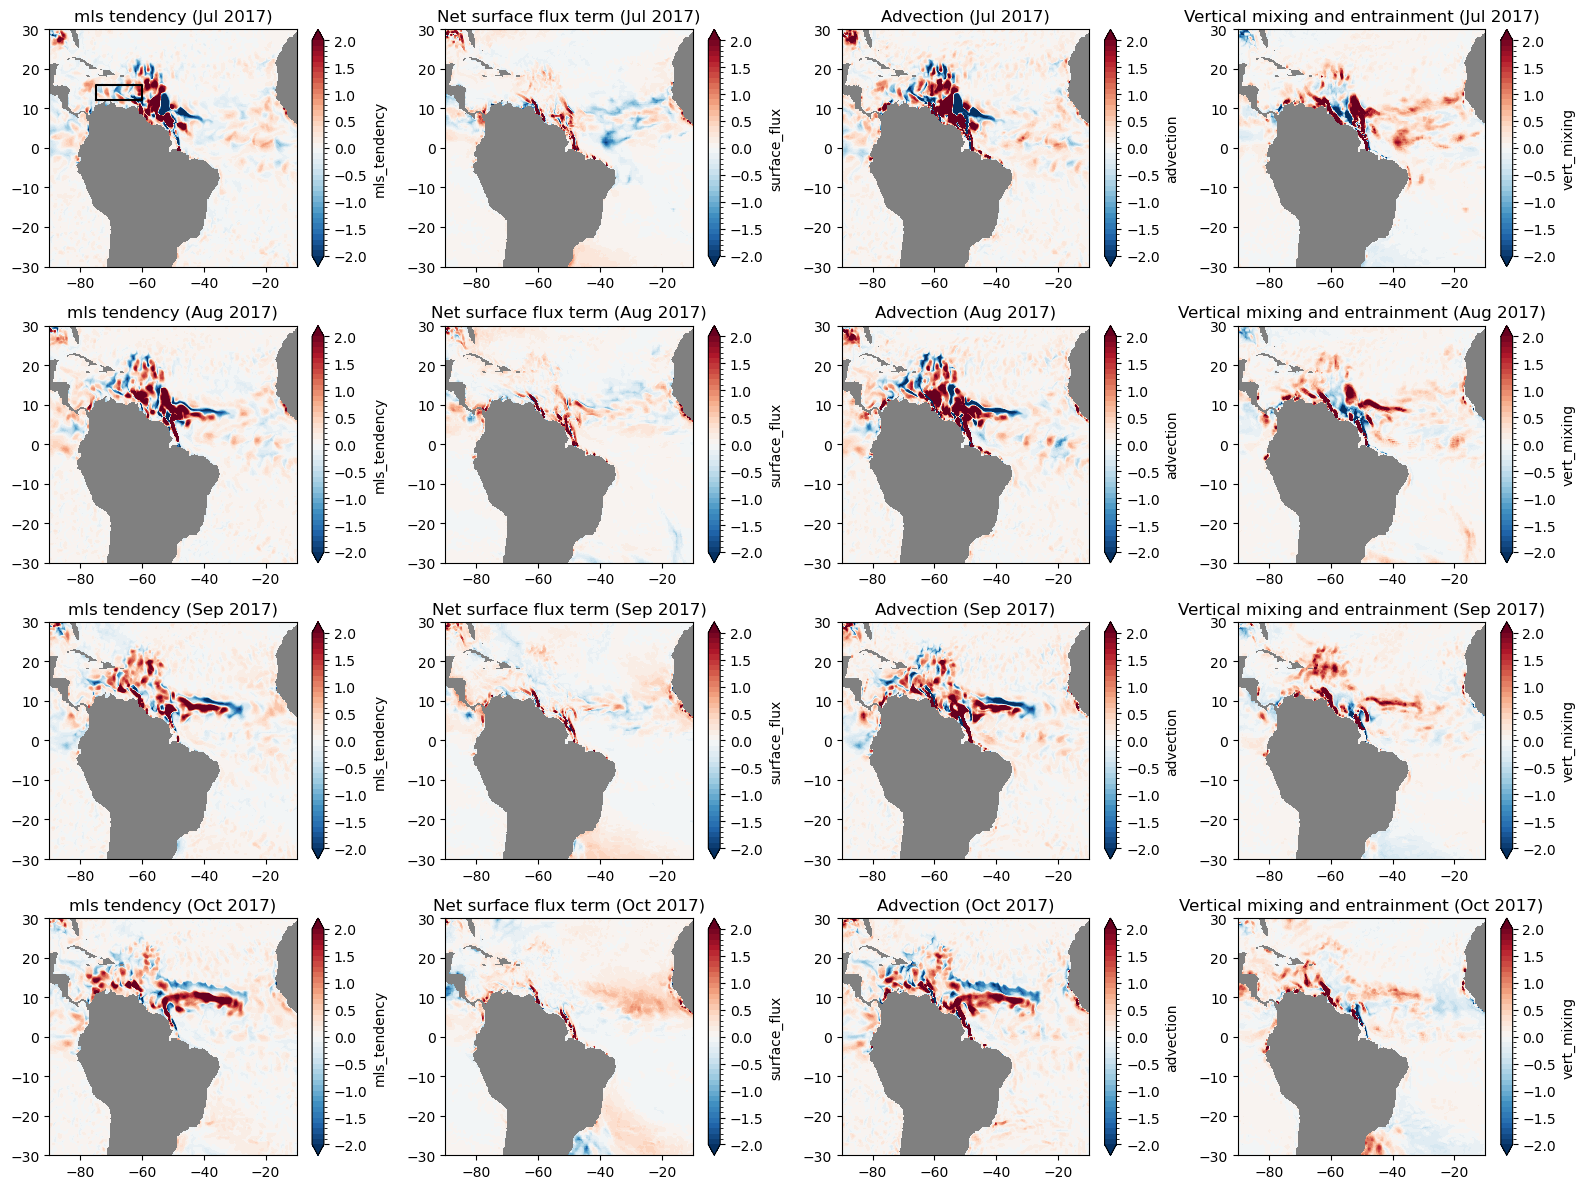

In [88]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16,12))
axs = axes.reshape(-1)

times = ['2017-07','2017-08','2017-09','2017-10']
time_labels = ['Jul 2017','Aug 2017','Sep 2017','Oct 2017']
vars = [['mls_tendency'],
        ['surface_flux'],
        ['advection'],
        ['vert_mixing','entrainment']]
names = ['mls tendency','Net surface flux term','Advection','Vertical mixing and entrainment']
clims = [-2.,2.]
unit_conv = 1.

for i,time in enumerate(times):
    budget_ti = anomaly_budget.sel(time=np.datetime64(time,'M'))*unit_conv

    for j, varg in enumerate(vars):
        ds = budget_ti[varg[0]]
        if len(varg)>1:
            for k in range(len(varg)-1):
                ds += budget_ti[varg[k+1]]
        ds.plot.contourf(ax=axes[i][j],levels=np.arange(-2.,2.1,0.1),cmap='RdBu_r')
        axes[i][j].set_title(names[j] + ' (' + time_labels[i] + ')')
        axes[i][j].set_xlabel('')
        axes[i][j].set_ylabel('')
        axes[i][j].set_facecolor([0.5,0.5,0.5])
        axes[i][j].set_xlim(reg[:2])
        axes[i][j].set_ylim([reg[2],reg[3]])

axes[0][0].plot([sreg[0],sreg[1],sreg[1],sreg[0],sreg[0]],[sreg[2],sreg[2],sreg[3],sreg[3],sreg[2]],'-k')
    
plt.tight_layout()
plt.savefig('mls_' + region_name.replace(' ','') + '_budget_spatial_2017.png',dpi=300,bbox_inches='tight')